# Decision Tree Random Forest #

### Imports ###



In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier



### Load Cleaned Dataset ###

In [2]:
script_dir = os.getcwd()
rel_path = "intermediate"

dataset = pd.read_csv(os.path.join(script_dir, rel_path, "CLEAN_data_injection_moulding.csv"))

### Feature Selection ###

Feature selection need not be too agressive. It's important just to check that we're feeding only process/ sensor variables. We will remove features that are almost always constant as well as irrelevant information.

In [3]:
features = [
    'ZSx [s]',        # injection time
    'ACPx [cm³]',     # cushion volume
    'ZDx [s]',        # dosing time
    # 'ZUs [s]',        # cycle time
    'ZEx [s]',        # (keep if it’s meaningful in your process)
    'GEx [kWh]',      # energy consumption
    'H16x [°C]',      # temperature 1
    'H10x [°C]'       # temperature 2
]
# features = ['ZSx [s]', 'ACPx [cm³]', 'ZDx [s]', 'ZEx [s]', 'APHu [bar]', 'GEx [kWh]', 'GPx [kW]', 'HPx [kW]', 'HEx [kWh]', 'MPx [kW]', 'ESPx [kWh/kg]', 'H16x [°C]', 'H15x [°C]', 'H10x [°C]', 'H12x [°C]', 'H9x [°C]', 'H11x [°C]']
X = dataset[features].copy()
y = dataset['ASZ [Sch]'].astype(int).copy()

print("X shape:", X.shape)
print("y positives:", y.sum(), " / ", len(y))


X shape: (4854, 7)
y positives: 163  /  4854


### Splitting and Scaling Data ###

In [4]:
def split_and_scale(X, y, test_size=0.2, random_state=42):
    # Stratify keeps defect ratio similar in train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )
    
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc = scaler.transform(X_test)
    
    return X_train, X_test, y_train, y_test, X_train_sc, X_test_sc, scaler

X_train, X_test, y_train, y_test, X_train_sc, X_test_sc, scaler = split_and_scale(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)
print("Train positives:", y_train.sum(), "Test positives:", y_test.sum())

Train size: (3883, 7) Test size: (971, 7)
Train positives: 130 Test positives: 33


### Baseline Model
This essentially does no machine learning and acts as a lower bound for comparison. It always just predicts the most frequent class. 

In [5]:
baseline = DummyClassifier(strategy="most_frequent", random_state=42)
baseline.fit(X_train, y_train)

y_pred_base = baseline.predict(X_test)

print("=== BASELINE ===")
print("F1:", f1_score(y_test, y_pred_base))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_base))
print(classification_report(y_test, y_pred_base, digits=3))

=== BASELINE ===
F1: 0.0
Confusion matrix:
 [[938   0]
 [ 33   0]]
              precision    recall  f1-score   support

           0      0.966     1.000     0.983       938
           1      0.000     0.000     0.000        33

    accuracy                          0.966       971
   macro avg      0.483     0.500     0.491       971
weighted avg      0.933     0.966     0.949       971



/run/media/leonpo/OS/Users/Admin/Desktop/KIT_unbacked/FifthSem/Spec/DataSci/challenge_machine_learning/.venv/lib64/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/run/media/leonpo/OS/Users/Admin/Desktop/KIT_unbacked/FifthSem/Spec/DataSci/challenge_machine_learning/.venv/lib64/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/run/media/leonpo/OS/Users/Admin/Desktop/KIT_unbacked/FifthSem/Spec/DataSci/challenge_machine_learning/.venv/lib64/python3.14/site-packages/sklearn/metrics/_c

### Decision Tree
Our decision trees might struggle with class imbalance because it may prioritize reducing overall error rather than focusing on our minority defect classes. Class weights solve this by assigning higher importance to minority classes during training. That's why we should select our class weight as balanced because defects are rare in our dataset. I also used mild regularization (max depth + min leaf size) to reduce overfitting

Stored 'y_pred_dt' (ndarray)


=== DECISION TREE ===
F1: 0.4732824427480916
Confusion matrix:
 [[871  67]
 [  2  31]]
              precision    recall  f1-score   support

           0      0.998     0.929     0.962       938
           1      0.316     0.939     0.473        33

    accuracy                          0.929       971
   macro avg      0.657     0.934     0.718       971
weighted avg      0.975     0.929     0.945       971



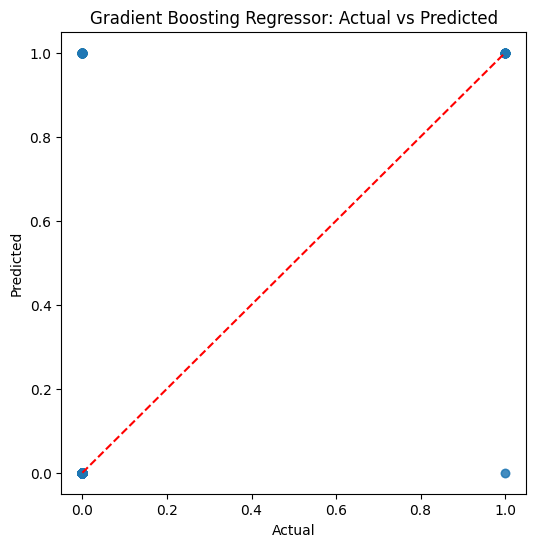

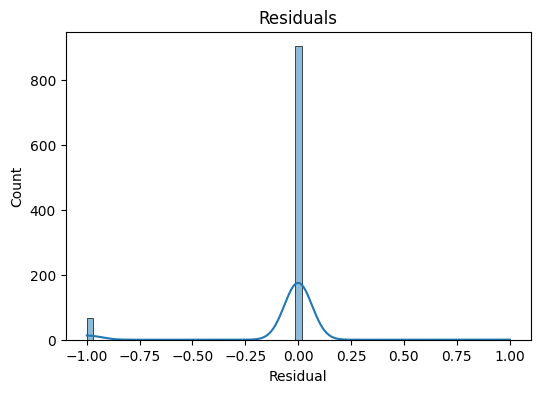

Feature importances:
 H16x [°C]     0.875538
ZSx [s]       0.050554
H10x [°C]     0.029637
ACPx [cm³]    0.025141
ZEx [s]       0.011276
GEx [kWh]     0.007811
ZDx [s]       0.000043
dtype: float64


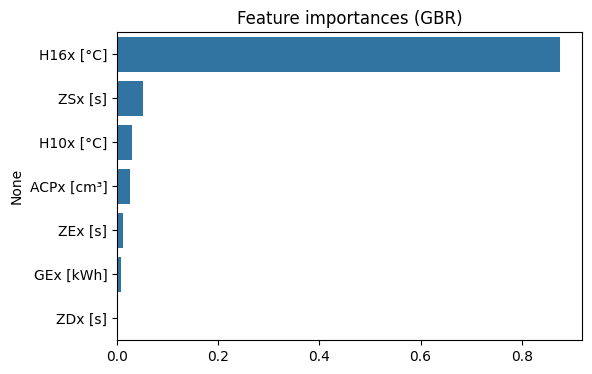

In [ ]:
dt = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced",
    max_depth=6,
    min_samples_leaf=10
)

dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)



print("=== DECISION TREE ===")
print("F1:", f1_score(y_test, y_pred_dt))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt, digits=3))

dt_cr = classification_report(y_test, y_pred_dt, digits=3)

# Actual vs Predicted
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_dt, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Gradient Boosting Regressor: Actual vs Predicted')
plt.show()

# Residuals
residuals = y_test - y_pred_dt
plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.title('Residuals')
plt.xlabel('Residual')
plt.show()

# Feature importances
importances = dt.feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)
print("Feature importances:\n", feat_imp)
plt.figure(figsize=(6,4))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title('Feature importances (GBR)')
plt.show()


### Decision Tree Feature Importance
This shows which features the tree relied on most. We can check if that makes sense physically (challenge introducted hinted that importance should align with process understanding)

In [7]:
dt_importance = pd.Series(dt.feature_importances_, index=features).sort_values(ascending=False)
dt_importance


H16x [°C]     0.875538
ZSx [s]       0.050554
H10x [°C]     0.029637
ACPx [cm³]    0.025141
ZEx [s]       0.011276
GEx [kWh]     0.007811
ZDx [s]       0.000043
dtype: float64

### Random Forest

As we know, a random forest reduces variance by averaging. We also see the forest’s feature importance ranking and can compare it to the decision tree to see which fits our process understanding.

In [ ]:
rf = RandomForestClassifier(
    random_state=42,
    n_estimators=500,
    class_weight="balanced_subsample",
    min_samples_leaf=5,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


print("=== RANDOM FOREST ===")
print("F1:", f1_score(y_test, y_pred_rf))
cm = confusion_matrix(y_test,y_pred_rf)
TP = cm[0][0]
FP = cm[1][0]
FN = cm[0][1]
TN = cm[1][1]

#for positive case
recall = TP/(TP+FN)
precision = TP/(TP+FP)

# for negative case
recall_n = TN/(TN+FN)
precision_n = TN/(TN+FP)

print("recall neg",recall)
print("precision neg",precision)

F1_S = 2*TP/(2*TP + FP + FN) 

F1_S2 = 2*TN/(2*TN + FP + FN) 

F1_again = 2*precision_n * recall_n/(precision_n + recall_n)

print("F1 again", F1_again)
print("Calculated F1",F1_S)
print("Calculated F12",F1_S)
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_rf))
rf_cr = classification_report(y_test, y_pred_rf, digits=3,output_dict=True)


print(classification_report(y_test, y_pred_rf, digits=3))

rf_importance = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
rf_importance


Stored 'y_pred_rf' (ndarray)
=== RANDOM FOREST ===
F1: 0.691358024691358
recall neg 0.9786780383795309
precision neg 0.9945828819068255
F1 again 0.691358024691358
Calculated F1 0.9865663621708759
Calculated F12 0.9865663621708759
Confusion matrix:
 [[918  20]
 [  5  28]]
              precision    recall  f1-score   support

           0      0.995     0.979     0.987       938
           1      0.583     0.848     0.691        33

    accuracy                          0.974       971
   macro avg      0.789     0.914     0.839       971
weighted avg      0.981     0.974     0.977       971



H16x [°C]     0.604882
GEx [kWh]     0.133143
ZSx [s]       0.080299
ZDx [s]       0.053493
H10x [°C]     0.051246
ACPx [cm³]    0.038989
ZEx [s]       0.037947
dtype: float64

In [ ]:
#storing the classification matricies for visuals
%store dt_cr rf_cr

### Compare Models 

Now we compare the models by using the F1 score

In [9]:
results = pd.DataFrame({
    "Model": ["Baseline", "Decision Tree", "Random Forest"],
    "F1": [
        f1_score(y_test, y_pred_base),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ]
}).sort_values("F1", ascending=False)






